In [2]:
from google.colab import drive
import os
import csv
from datetime import datetime

drive.mount('/content/drive')
new_dir = "/content/drive/My Drive/566project"
os.chdir(new_dir)
current_dir = os.getcwd()
print(f"new directory: {current_dir}")

Mounted at /content/drive
new directory: /content/drive/My Drive/566project


In [4]:
!pip install scapy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.2 MB/s eta 0:00:00


In [5]:
import ipaddress
import numpy as np
import pandas as pd
from scapy.all import RawPcapReader, Ether, IP, IPv6, UDP, DNS, DNSQR
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from torch.utils.data import DataLoader, TensorDataset

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import joblib

import random

In [ ]:
# data preprocess
def preprocess_pcap(pcap_file: str, csv_file: str):
    """
    Extract DNS query packets from a pcap file and save to CSV.
    Fields: domain, timestamp, qtype, rcode, src_ip
    Only includes DNS query (qr=0) packets.
    """
    import csv
    from scapy.all import RawPcapReader, Ether, IP, IPv6, UDP, DNS
    from datetime import datetime

    count = 0
    with open(csv_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['domain', 'timestamp', 'qtype', 'rcode', 'src_ip'])

        reader = RawPcapReader(pcap_file)
        for pkt_data, pkt_metadata in reader:
            try:
                eth = Ether(pkt_data)
                if eth.haslayer(IP):
                    pkt = eth[IP]
                elif eth.haslayer(IPv6):
                    pkt = eth[IPv6]
                else:
                    continue

                if not (pkt.haslayer(UDP) and pkt.haslayer(DNS)):
                    continue

                dns = pkt[DNS]
                if dns.qr != 0 or dns.qdcount == 0:
                    continue

                domain = dns.qd.qname.decode(errors='ignore').rstrip('.').lower()
                if not domain or '.' not in domain:
                    continue

                timestamp = datetime.fromtimestamp(pkt_metadata.sec + pkt_metadata.usec / 1e6)
                qtype = dns.qd.qtype
                rcode = dns.rcode
                src_ip = pkt.src

                writer.writerow([domain, timestamp, qtype, rcode, src_ip])
                count += 1
            except Exception:
                continue

    print(f"[Done] Extracted {count} DNS query records to {csv_file}")


In [ ]:
# only 7 seconds range.
pcap_file = '20210118-000053-01906485.lax.pcap'
csv_file = 'dns_queries_20210118_lax.csv'

preprocess_pcap(pcap_file, csv_file)

In [ ]:
pcap_file = '20210118-000020-00460916.mia.pcap'
csv_file = 'dns_queries_20210118_mia.csv'

preprocess_pcap(pcap_file, csv_file)

In [6]:
def extract_features(csv_file: str) -> pd.DataFrame:
    """
    Extract domain-level behavioral features from a DNS query log CSV
    generated by preprocess_pcap().

    Args:
        csv_file (str): Path to the CSV file containing raw DNS query logs.

    Returns:
        pd.DataFrame: A dataframe where each row represents one domain,
                      with extracted behavioral statistics.
    """
    df = pd.read_csv(csv_file, parse_dates=['timestamp'])

    # Normalize domain names: lowercase and strip trailing dot
    df['domain'] = df['domain'].str.lower().str.rstrip('.')

    grouped = df.groupby('domain')
    rows = []

    for domain, group in grouped:
        total_queries = len(group)
        a_queries = (group['qtype'] == 1).sum()
        aaaa_queries = (group['qtype'] == 28).sum()
        unique_ips = group['src_ip'].nunique()

        # Compute burstiness: standard deviation of inter-arrival times (in seconds)
        timestamps = group['timestamp'].astype(np.int64) // 1_000_000_000
        intervals = np.diff(timestamps) if len(timestamps) > 1 else np.array([0])
        burstiness = np.std(intervals)

        # NXDOMAIN ratio: proportion of queries that returned NXDOMAIN (rcode == 3)
        nxdomain_rate = (group['rcode'] == 3).mean()

        rows.append({
            'domain': domain,
            'total_queries': total_queries,
            'A_queries': a_queries,
            'AAAA_queries': aaaa_queries,
            'unique_ips': unique_ips,
            'burstiness': burstiness,
            'nxdomain_rate': nxdomain_rate
        })

    return pd.DataFrame(rows)

In [7]:
features_df = extract_features("dns_queries_20210118_mia.csv")

In [9]:
print(features_df.head())
print(features_df.shape)

                       domain  total_queries  A_queries  AAAA_queries  \
0          %23.localdomain             12         12             0   
1                  .dap-1860              1          0             1   
2  x\t\n-r r.localdomain              1          1             0   
3   x#\n\n }.localdomain              1          1             0   
4  xq\t\nmv v.localdomain              1          1             0   

   unique_ips  burstiness  nxdomain_rate  
0           1     4.33704            0.0  
1           1     0.00000            0.0  
2           1     0.00000            0.0  
3           1     0.00000            0.0  
4           1     0.00000            0.0  
(95107, 7)


In [10]:
# Step 1: Copy original
filtered_df = features_df.copy()

# Step 2: Filter domains with total_queries > 1
filtered_df = filtered_df[filtered_df['total_queries'] > 1]

# (Optional) Step 3: Further filter to those seen by multiple source IPs
filtered_df = filtered_df[filtered_df['unique_ips'] > 1]

# (Optional) Step 4: Keep those with measurable burstiness
filtered_df = filtered_df[filtered_df['burstiness'] > 0]

print(f"Filtered dataset shape: {filtered_df.shape}")

Filtered dataset shape: (5206, 7)


In [11]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [13]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Normalize
feature_cols = [
    'total_queries', 'A_queries', 'AAAA_queries',
    'unique_ips', 'burstiness', 'nxdomain_rate'
]

scaler = StandardScaler()
# X = scaler.fit_transform(features_df[feature_cols])
X = scaler.fit_transform(filtered_df[feature_cols])

joblib.dump(scaler, 'scaler.pkl')

# prepare data
tensor = torch.tensor(X, dtype=torch.float32)
total = tensor.size(0)
train_end = int(0.625 * total)
val_end = int(0.875 * total)
train_data = tensor[:train_end]
val_data = tensor[train_end:val_end]
test_data = tensor[val_end:]

batch_size = 128
train_loader = DataLoader(TensorDataset(train_data), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_data), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(test_data), batch_size=batch_size, shuffle=False)

In [20]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model and optimizer
model = Autoencoder(input_dim=X.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training config
train_loss, val_loss = [], []
best_val_loss = float('inf')
patience, no_improve = 30, 0
num_epochs = 300
best_model_state = None

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)  # send to GPU
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    train_loss.append(epoch_train_loss / len(train_loader))

    # Validation
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)  # send to GPU
            output = model(batch)
            loss = criterion(output, batch)
            epoch_val_loss += loss.item()
    val_loss.append(epoch_val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss[-1]:.6f} | Val Loss: {val_loss[-1]:.6f}")

    # Save best model
    if val_loss[-1] < best_val_loss - 1e-4:
        best_val_loss = val_loss[-1]
        best_model_state = model.state_dict()
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Restore best weights
if best_model_state:
    model.load_state_dict(best_model_state)

# Save model parameters (state_dict)
torch.save(model.state_dict(), "ae_model.pth")

Epoch 1/300 | Train Loss: 0.923112 | Val Loss: 0.786356
Epoch 2/300 | Train Loss: 0.904666 | Val Loss: 0.773500
Epoch 3/300 | Train Loss: 0.904727 | Val Loss: 0.728619
Epoch 4/300 | Train Loss: 0.818491 | Val Loss: 0.511211
Epoch 5/300 | Train Loss: 0.716963 | Val Loss: 0.471728
Epoch 6/300 | Train Loss: 0.597198 | Val Loss: 0.486026
Epoch 7/300 | Train Loss: 0.584057 | Val Loss: 0.475954
Epoch 8/300 | Train Loss: 0.428502 | Val Loss: 0.456914
Epoch 9/300 | Train Loss: 0.368210 | Val Loss: 0.443794
Epoch 10/300 | Train Loss: 0.314886 | Val Loss: 0.483431
Epoch 11/300 | Train Loss: 0.276271 | Val Loss: 0.440685
Epoch 12/300 | Train Loss: 0.250685 | Val Loss: 0.436157
Epoch 13/300 | Train Loss: 0.216981 | Val Loss: 0.470795
Epoch 14/300 | Train Loss: 0.258276 | Val Loss: 0.465068
Epoch 15/300 | Train Loss: 0.235837 | Val Loss: 0.453575
Epoch 16/300 | Train Loss: 0.234980 | Val Loss: 0.449233
Epoch 17/300 | Train Loss: 0.177395 | Val Loss: 0.449202
Epoch 18/300 | Train Loss: 0.182679 | Va

In [21]:
# === Test Set Evaluation  ===
model.eval()
test_loss = 0.0
with torch.no_grad():
    for (batch,) in test_loader:
        output = model(batch)
        loss = criterion(output, batch)
        test_loss += loss.item()
avg_test_loss = test_loss / len(test_loader)
print(f"\nTest Loss: {avg_test_loss:.6f}")


Test Loss: 0.025718


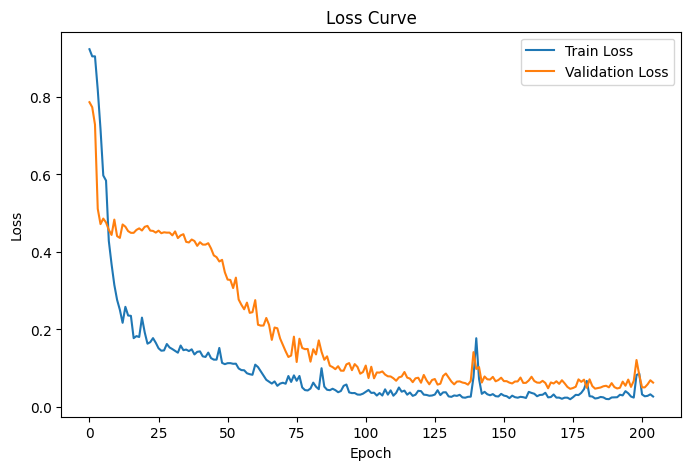

In [22]:
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.show()

plot_loss(train_loss, val_loss)

In [30]:
# Move model and input to appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

# Compute reconstruction and latent vectors
with torch.no_grad():
    recon = model(X_tensor).cpu().numpy()
    latent_vectors = model.encoder(X_tensor).cpu().numpy()

# Compute MSE reconstruction errors per sample
reconstruction_errors = np.mean((X - recon) ** 2, axis=1)

In [31]:
# Attach reconstruction errors to the filtered dataframe
filtered_df = filtered_df.reset_index(drop=True).copy()
filtered_df['recon_error'] = reconstruction_errors

# Print domains with highest and lowest reconstruction errors
top_n = 20
high_error_domains = filtered_df.sort_values(by='recon_error', ascending=False).head(top_n)
low_error_domains = filtered_df.sort_values(by='recon_error', ascending=True).head(top_n)

print("\nDomains with High Reconstruction Error:")
print(high_error_domains[['domain', 'recon_error']])

print("\nDomains with Low Reconstruction Error:")
print(low_error_domains[['domain', 'recon_error']])


Domains with High Reconstruction Error:
                         domain  recon_error
3550         ns1.pc-network.net   860.466736
3782         ns2.pc-network.net   815.552068
2872                   ip6.arpa   404.362614
2343              hostname.bind   108.930466
2438               in-addr.arpa    71.538850
3053         m.root-servers.net    55.572841
4434             rsyslogd.local    50.079801
1492  cs0001.adn.omicroncdn.net    44.565129
436          a.gtld-servers.net    34.679607
2959         l.root-servers.net    25.650709
4642             tm1.dns-tm.com    17.650205
1124         b.root-servers.net    16.190130
5074         www.hik-online.com    15.313939
472          a.root-servers.net    15.129388
4644             tm2.dns-tm.com    14.280021
4643        tm1.edgedns-tm.info    14.083293
4366     r._dns-sd._udp.y^za    13.718769
2991          lb._dns-sd._udp.`    13.703545
4368           r._dns-sd._udp.߁    13.658909
1079           b._dns-sd._udp.߁    13.658909

Domains with 

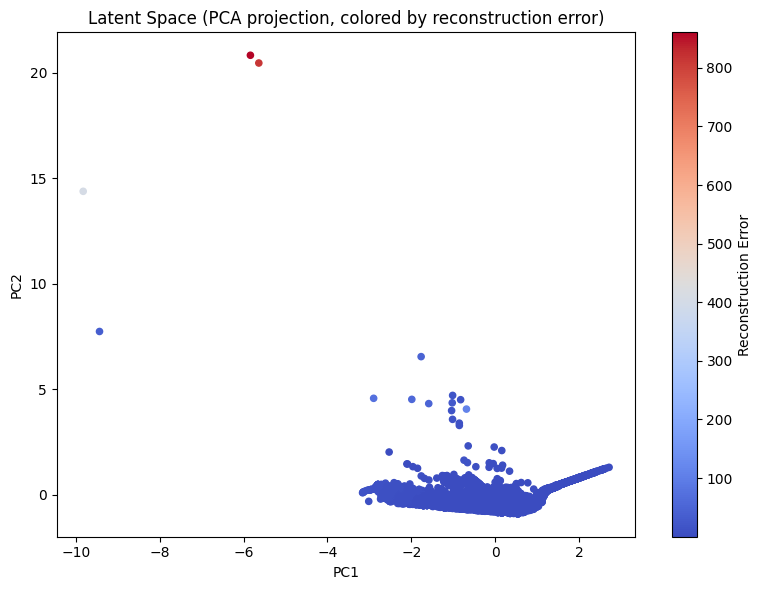

In [33]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Project latent space to 2D using PCA
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

# Plot latent space with color indicating reconstruction error
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latent_2d[:, 0], latent_2d[:, 1],
    c=reconstruction_errors,
    cmap='coolwarm',
    s=20
)
plt.colorbar(scatter, label="Reconstruction Error")
plt.title("Latent Space (PCA projection, colored by reconstruction error)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [41]:
# Extract top-N domains by reconstruction error
top_anomalies = filtered_df.sort_values(by='recon_error', ascending=False).head(top_n)

# Show feature values for these domains
print("\nTop domains with highest reconstruction error and their behavioral features:")
print(top_anomalies[[
    'domain', 'recon_error',
    'total_queries', 'A_queries', 'AAAA_queries',
    'unique_ips', 'burstiness', 'nxdomain_rate',
    'cluster_id'
]])


Top domains with highest reconstruction error and their behavioral features:
                         domain  recon_error  total_queries  A_queries  \
3550         ns1.pc-network.net   860.466736            635          0   
3782         ns2.pc-network.net   815.552068            628          0   
2872                   ip6.arpa   404.362614           1470       1466   
2343              hostname.bind   108.930466            654          0   
2438               in-addr.arpa    71.538850            554        527   
3053         m.root-servers.net    55.572841            515        280   
4434             rsyslogd.local    50.079801            389        215   
1492  cs0001.adn.omicroncdn.net    44.565129            436        212   
436          a.gtld-servers.net    34.679607           1078       1072   
2959         l.root-servers.net    25.650709            310        111   
4642             tm1.dns-tm.com    17.650205            285        138   
1124         b.root-servers.net   